# Correlación y Selección de Variables

En este notebook se analiza la relación entre las variables del dataset con el objetivo de identificar cuáles pueden tener mayor influencia en la cancelación de clientes (*churn*).

Para ello se realizará un análisis de **correlación entre variables numéricas**, prestando especial atención a aquellas que muestran una relación más fuerte con la variable objetivo `abandono`.

Este análisis permitirá:

- Identificar variables que podrían ser **buenos predictores del churn**.
- Detectar posibles **relaciones fuertes entre variables**, lo que podría indicar redundancia o multicolinealidad.
- Comprender mejor la estructura del dataset antes de entrenar los modelos de Machine Learning.

El análisis se realizará utilizando **matrices de correlación y visualizaciones** que faciliten la interpretación de las relaciones entre las variables.

##Montar el Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


##Importamos las librerías necesarias

In [2]:
import os
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

##Definimos la ruta del proyecto

In [3]:
PROJECT_PATH = "/content/drive/MyDrive/TelecomX_Churn_ML"

DATA_PATH = os.path.join(PROJECT_PATH, "data", "processed")

encoded_path = os.path.join(DATA_PATH, "TelecomX_encoded.csv")

print("Ruta del dataset:", encoded_path)

Ruta del dataset: /content/drive/MyDrive/TelecomX_Churn_ML/data/processed/TelecomX_encoded.csv


##Cargamos el dataset codificado

In [4]:
df = pd.read_csv(encoded_path)

df.head()

,abandono,adulto_mayor,tiene_pareja,tiene_dependientes,antiguedad_meses,servicio_telefono,lineas_multiples,proteccion_dispositivo,soporte_tecnico,streaming_tv,...,servicio_internet_No,seguridad_online_No internet service,seguridad_online_Yes,respaldo_online_No internet service,respaldo_online_Yes,tipo_contrato_One year,tipo_contrato_Two year,metodo_pago_Credit card (automatic),metodo_pago_Electronic check,metodo_pago_Mailed check
0,0,0,1,1,9,1,0,0,1,1,...,False,False,False,False,True,True,False,False,False,True
1,0,0,0,0,9,1,1,0,0,0,...,False,False,False,False,False,False,False,False,False,True
2,1,0,0,0,4,1,0,1,0,0,...,False,False,False,False,False,False,False,False,True,False
3,1,1,1,0,13,1,0,1,0,1,...,False,False,False,False,True,False,False,False,True,False
4,1,1,1,0,3,1,0,0,1,1,...,False,False,False,False,False,False,False,False,False,True


##Revisamos las dimensiones del dataset

In [5]:
print("Dimensiones del dataset:", df.shape)

Dimensiones del dataset: (7032, 27)


##Calculamos la matrix de correlación

In [6]:
matrix_correlacion = df.corr()

matrix_correlacion.head()

,abandono,adulto_mayor,tiene_pareja,tiene_dependientes,antiguedad_meses,servicio_telefono,lineas_multiples,proteccion_dispositivo,soporte_tecnico,streaming_tv,...,servicio_internet_No,seguridad_online_No internet service,seguridad_online_Yes,respaldo_online_No internet service,respaldo_online_Yes,tipo_contrato_One year,tipo_contrato_Two year,metodo_pago_Credit card (automatic),metodo_pago_Electronic check,metodo_pago_Mailed check
abandono,1.000000,0.150541,-0.149982,-0.163128,-0.354049,0.011691,0.040033,-0.066193,-0.164716,0.063254,...,-0.227578,-0.227578,-0.171270,-0.227578,-0.082307,-0.178225,-0.301552,-0.134687,0.301455,-0.090773
adulto_mayor,0.150541,1.000000,0.016957,-0.210550,0.015683,0.008392,0.142996,0.059514,-0.060577,0.105445,...,-0.182519,-0.182519,-0.038576,-0.182519,0.066663,-0.046491,-0.116205,-0.024359,0.171322,-0.152987
tiene_pareja,-0.149982,0.016957,1.000000,0.452269,0.381912,0.018397,0.142561,0.153556,0.120206,0.124483,...,-0.000286,-0.000286,0.143346,-0.000286,0.141849,0.083067,0.247334,0.082327,-0.083207,-0.096948
tiene_dependientes,-0.163128,-0.210550,0.452269,1.000000,0.163386,-0.001078,-0.024307,0.013900,0.063053,-0.016499,...,0.138383,0.138383,0.080786,0.138383,0.023639,0.069222,0.201699,0.061134,-0.149274,0.056448
antiguedad_meses,-0.354049,0.015683,0.381912,0.163386,1.000000,0.007877,0.332399,0.361520,0.325288,0.280264,...,-0.037529,-0.037529,0.328297,-0.037529,0.361138,0.202338,0.563801,0.232800,-0.210197,-0.232181


##Visualizamos la matrix de correlación

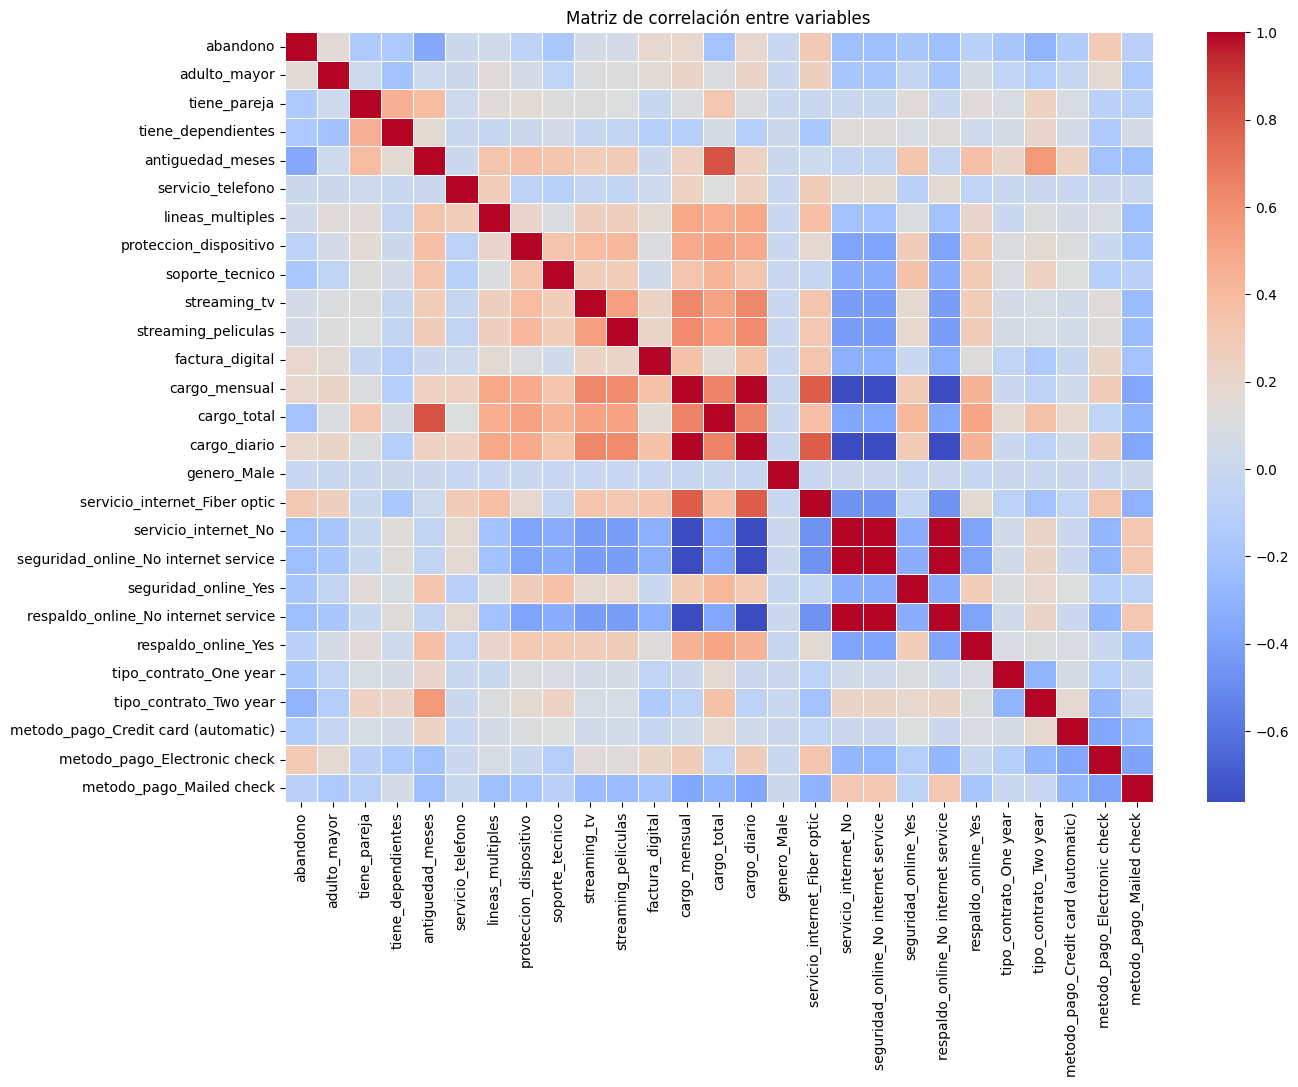

In [7]:
plt.figure(figsize=(14,10))

sns.heatmap(
    matrix_correlacion,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Matriz de correlación entre variables")
plt.show()

In [8]:
correlacion_objetivo = matrix_correlacion["abandono"].sort_values(ascending=False)

correlacion_objetivo

,abandono
abandono,1.000000
servicio_internet_Fiber optic,0.307463
metodo_pago_Electronic check,0.301455
cargo_diario,0.192858
cargo_mensual,0.192858
factura_digital,0.191454
adulto_mayor,0.150541
streaming_tv,0.063254
streaming_peliculas,0.060860
lineas_multiples,0.040033


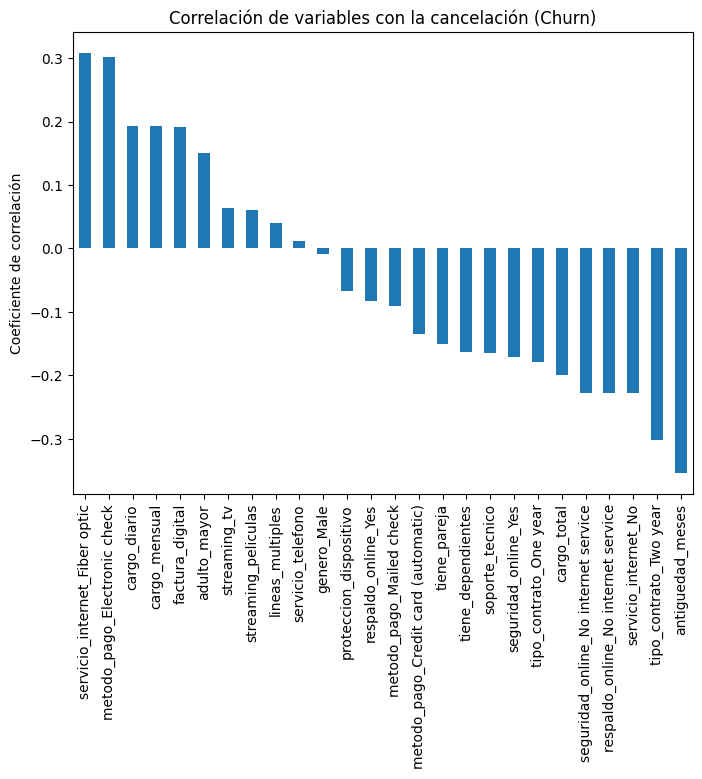

In [10]:
correlacion_objetivo.drop("abandono").plot(
    kind="bar",
    figsize=(8,6)
)

plt.title("Correlación de variables con la cancelación (Churn)")
plt.ylabel("Coeficiente de correlación")
plt.show()

###El análisis de correlación muestra que variables como la antigüedad del cliente, el tipo de contrato, el método de pago y el tipo de servicio de internet presentan una relación significativa con la cancelación del servicio.

###Estas variables se consideran candidatas importantes para los modelos predictivos que se entrenarán en las siguientes etapas del proyecto.

## Análisis dirigido de variables relevantes

Después de analizar la matriz de correlación, se realiza un análisis más detallado de algunas variables clave para entender mejor su relación con la cancelación de clientes.

En particular se analizarán:

- Antigüedad del cliente (antiguedad_meses) × Cancelación
- Gasto total (cargo_total) × Cancelación

Estos análisis permiten identificar patrones y tendencias que pueden ayudar a comprender mejor los factores asociados al churn.

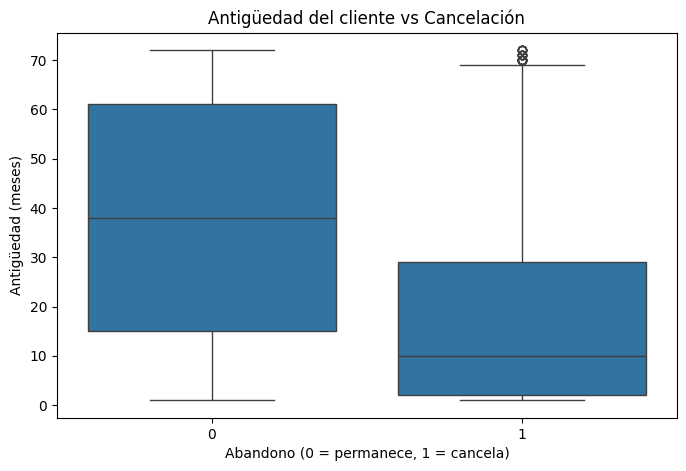

In [11]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="abandono",
    y="antiguedad_meses",
    data=df
)

plt.title("Antigüedad del cliente vs Cancelación")
plt.xlabel("Abandono (0 = permanece, 1 = cancela)")
plt.ylabel("Antigüedad (meses)")

plt.show()

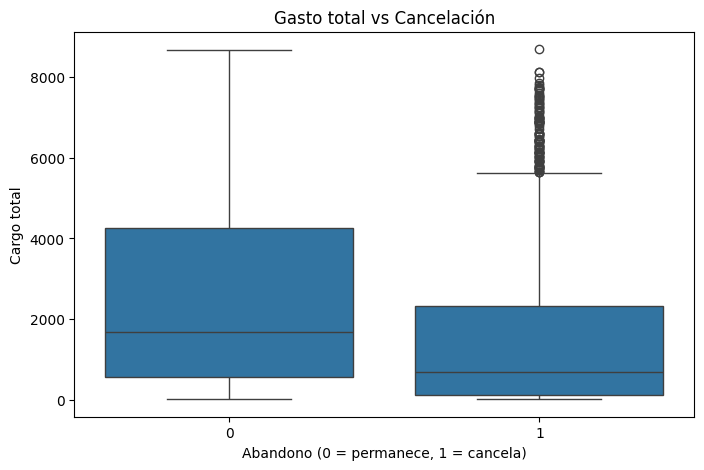

In [12]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="abandono",
    y="cargo_total",
    data=df
)

plt.title("Gasto total vs Cancelación")
plt.xlabel("Abandono (0 = permanece, 1 = cancela)")
plt.ylabel("Cargo total")

plt.show()

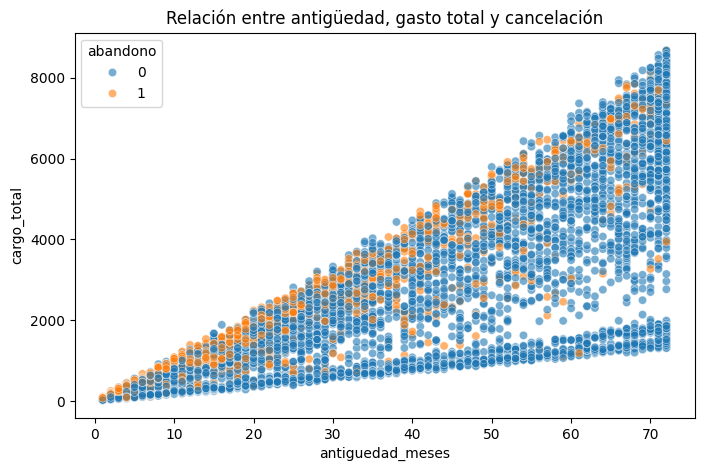

In [13]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="antiguedad_meses",
    y="cargo_total",
    hue="abandono",
    data=df,
    alpha=0.6
)

plt.title("Relación entre antigüedad, gasto total y cancelación")

plt.show()

## Conclusiones del análisis dirigido

A partir de los gráficos generados se pueden identificar varios patrones importantes en relación con la cancelación de clientes (churn).

### Antigüedad del cliente y cancelación

El análisis de la variable **antiguedad_meses** muestra que los clientes que cancelan el servicio suelen tener una **menor antigüedad** en comparación con aquellos que permanecen activos.  
La mediana de antigüedad para los clientes que cancelan es considerablemente menor, lo que sugiere que los primeros meses de relación con la empresa representan un período crítico para la retención de clientes.

### Gasto total y cancelación

El análisis del **cargo_total** indica que los clientes que cancelan tienden a presentar **menores niveles de gasto acumulado**, mientras que aquellos que permanecen en la empresa muestran valores más altos.  
Esto se relaciona directamente con la antigüedad del cliente, ya que quienes permanecen más tiempo naturalmente acumulan un mayor gasto total.

### Relación entre antigüedad, gasto total y cancelación

El gráfico de dispersión muestra una **relación positiva entre la antigüedad del cliente y el gasto total**, lo cual era esperado dado que el gasto acumulado aumenta con el tiempo.  
Además, se observa que la mayor concentración de cancelaciones ocurre entre clientes con **menor antigüedad y menor gasto total**, lo que refuerza la idea de que los clientes más nuevos tienen mayor probabilidad de abandonar el servicio.

### Insight general

Estos resultados sugieren que la cancelación de clientes está fuertemente asociada con el tiempo que llevan en la empresa y el gasto acumulado. Por lo tanto, implementar estrategias de retención enfocadas en los **clientes durante sus primeros meses de servicio** podría ayudar a reducir la tasa de churn.

In [15]:
output_path = "/content/drive/MyDrive/TelecomX_Churn_ML/data/processed/TelecomX_model_ready.csv"

df.to_csv(output_path, index=False)

print("Dataset guardado correctamente en:")
print(output_path)

Dataset guardado correctamente en:
/content/drive/MyDrive/TelecomX_Churn_ML/data/processed/TelecomX_model_ready.csv
